In [ ]:
# 실습 준비 — 08주차 대표적인 연속형 확률분포
# 이 셀을 먼저 한 번 실행하세요. 데이터가 없으면 아래 셀들이 전부 실패합니다.
import os, pathlib, urllib.request

BASE = "https://raw.githubusercontent.com/aprilslab/statistics-lab/main/data/"
FILES = []

pathlib.Path("data").mkdir(exist_ok=True)
for name in FILES:
    for dest in (pathlib.Path(name), pathlib.Path("data") / name):
        if not dest.exists():
            urllib.request.urlretrieve(BASE + name, dest)

# '../data/x.csv' 로 읽는 노트북 대응 — 상위 폴더에도 같은 data/ 를 걸어둔다.
# 절대경로(/data)로 박으면 cwd 가 /content 가 아닐 때 깨지므로 상대경로로 건다.
try:
    parent = pathlib.Path("..") / "data"
    if not parent.exists():
        os.symlink(pathlib.Path("data").resolve(), parent)
except OSError:
    pass

print("준비 완료:", ", ".join(FILES) if FILES else "(내려받을 데이터 없음)")


# 대표적인 연속형 확률분포

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate
from scipy.optimize import minimize_scalar

%precision 3
%matplotlib inline

* $E(X)$ : **기댓값** 함수
* $V(X)$ : **분산** 함수
* check_prob : **확률의 성질** 만족하는지 확인 후, **기댓값**과 **분산** 계산
* plot_prob : **확률변수(X)** 와 **구간(min, max)** 을 인수로 취하고, 그 확률변수의 **밀도함수**와 **분포함수**를 그리는 함수

In [ ]:
linestyles = ['-', '--', ':']

def E(X, g=lambda x: x):
    x_range, f = X
    def integrand(x):
        return g(x) * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

def V(X, g=lambda x: x):
    x_range, f = X
    mean = E(X, g)
    def integrand(x):
        return (g(x) - mean) ** 2 * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

def check_prob(X):
    x_range, f = X
    f_min = minimize_scalar(f).fun
    assert f_min >= 0, 'density function is minus value'
    prob_sum = np.round(integrate.quad(f, -np.inf, np.inf)[0], 6)
    assert prob_sum == 1, f'sum of probability is {prob_sum}'
    print(f'expected vaue {E(X):.3f}')
    print(f'variance {V(X):.3f}')

def plot_prob(X, x_min, x_max):
    x_range, f = X
    def F(x):
        return integrate.quad(f, -np.inf, x)[0]

    xs = np.linspace(x_min, x_max, 100)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.plot(xs, [f(x) for x in xs],
            label='f(x)', color='gray')
    ax.plot(xs, [F(x) for x in xs],
            label='F(x)', ls='--', color='gray')

    ax.legend()
    plt.show()

## 정규분포
* 통계분석에서 매우 자주 사용되는 중요한 확률변수로, 자연계에서 일어나는 수많은 현상을 표현할 수 있다. (가우스 분포라도고 함)
* 취할 수 있는 값: 실수 전체
* 파라미터 $\mu, \sigma^2$인 정규분포 표기법: $N(\mu, \sigma^2)$
<br>

### 정규분포의 밀도함수
$$
f(x) = \frac1{\sqrt{2\pi\sigma}}exp\left\{-\frac{{(x-\mu)}^2}{2\sigma^2}\right\} \;\; (-\infty < x < \infty)
$$

\
예) 남자고등학생의 키
* 키의 평균: 170cm, 표준편차: 5cm
* $ N(170,5^2)$을 따름
* 우연히 만난 남자 고등학생의 **키가 165cm 이상 175cm 이하**일 확률
$$
P(165 \le X \le 175) = \int_{165}^{175} \frac1{\sqrt{2\pi}\times5}exp\left\{-\frac{(x-170)^2}{2\times5^2}\right\}dx \simeq 0.683
$$

\
예) 모의고사 점수
* 평균 점수: 70점, 표준편차: 8점
* $N(70, 8^2)$을 따름
* 우연히 만난 학생의 **점수가 54점 이상 86점 이하**일 확률
$$
P(54 \le X \le 86) = \int_{54}^{86} \frac1{\sqrt{2\pi}\times8}exp\left\{-\frac{(x-70)^2}{2\times8^2}\right\}dx \simeq 0.954
$$
<br>

#### 정규분포의 기댓값과 분산
<center>$X \sim N(\mu, \sigma^2)$이라고 할 때</center><br>
$$
E(X) = \mu, V(X) = \sigma^2
$$
<br>

#### 정규분포의 변환
<center>
$X \sim N(\mu, \sigma^2)$이라고 할 때, 임의의 실수 $a, b$에 대해서
</center>
<br>
$$
aX + b \sim N(a\mu + b, a^2\sigma^2)
$$
<br>
<center>이 성립하는 성질을 이용하여</center>
<br>

<center>$X \sim N(\mu, \sigma^2)$을 정규화한 확률변수
<br><br>
$$
Z=\frac{X-\mu}{\sigma}\text{는 } $N(0,1) \text{을 따름}
$$
<br>
을 알 수 있음.
</center>



In [ ]:
# 정규분포의 가능한 값과, 밀도함수 리턴
def N(mu, sigma):
    x_range = [- np.inf, np.inf]
    def f(x):
        return 1 / np.sqrt(2 * np.pi * sigma**2) *\
                    np.exp(-(x-mu)**2 / (2 * sigma**2))
    return x_range, f

<br>
$N(2, 0.5^{2})$을 따르는 확률변수 $X$작성

In [ ]:
mu, sigma = 2, 0.5
X = N(mu, sigma)

<br>
기댓값과 분산확인

In [ ]:
check_prob(X)

expected vaue 2.000
variance 0.250


<br>
밀도함수와 분포함수를 0과 4사이에서 그려본다

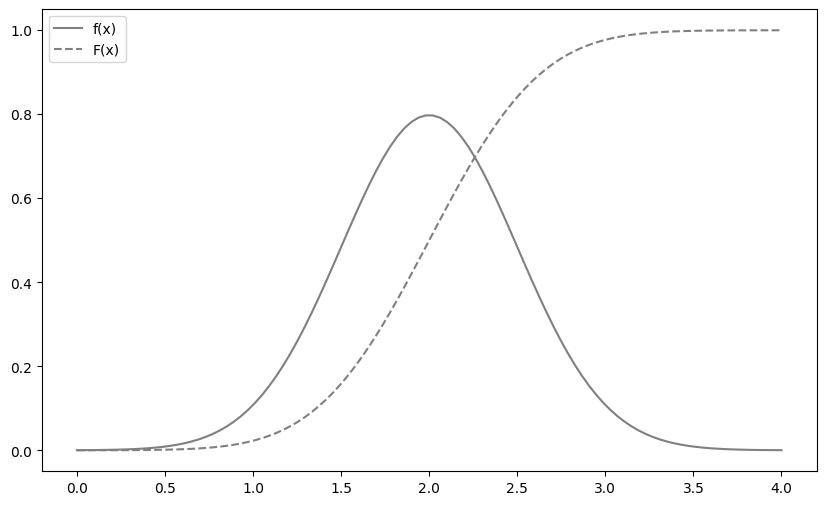

In [ ]:
plot_prob(X, 0, 4)

<br>
기댓값이 2dlrh 표준편차가 0.5인 정규분포를 따르는 확률변수 생성

In [ ]:
rv = stats.norm(2, 0.5)

<br>
기댓값과 분산

In [ ]:
rv.mean(), rv.var()

(np.float64(2.0), np.float64(0.25))

<br>
밀도함수 계산 (결과값이 확률아님 주의)

In [ ]:
rv.pdf(2)

np.float64(0.7978845608028654)

<br>
분포함수 계산 (결과값 확률 맞음)

In [ ]:
# 1.7 보다 작은 값이 되는 확률
rv.cdf(1.7)

np.float64(0.27425311775007355)

#### 상위 $100_\alpha\%$점 계산
* $P(X \ge x) = \alpha$를 만족하는 $x$
* 정규분포의 상위 $100_\alpha\%$점 표기법: $Z_\alpha$
* 계산: isf메서드

<br>
상위 30% 지점.

In [ ]:
rv.isf(0.3)

np.float64(2.2622002563540207)

$z_\alpha$는 $Z \sim N(0,1)$이라 할 때, 정규분포는 $x=0$을 중심으로 대칭이기 때문에 $z_{1-\alpha} = -z_\alpha$가 성립함.

In [ ]:
rv2 = stats.norm(0,1)
rv2.isf(0.3), rv2.isf(0.7)

(np.float64(0.5244005127080409), np.float64(-0.5244005127080407))

<br>
상위 90% 지점.

In [ ]:
rv.interval(0.9)

(np.float64(1.1775731865242636), np.float64(2.822426813475736))

<br>
왼쪽과 오른쪽에 각각 5%씩 남아있기 때문에, 다음과 같이 구할 수도 있다.

In [ ]:
rv.isf(0.95), rv.isf(0.05)

(np.float64(1.1775731865242638), np.float64(2.8224268134757367))

표준정규분포의 경우 $100(1-\alpha)\%$구간은 $z_\alpha$를 사용하여 $\left[ z_{1-\alpha/2},z_{\alpha/2} \right]$로 나타낼 수 있다.

\
예)
표준정규분포의 95%구간의 $\alpha = 0.05$에 대응하므로 $\alpha/2 = 0.025$이고 $\left[ z_{0.975},z_{0.025} \right]$로 나타낼 수 잇다.

<br> 파라미터에 따른 정규분포의 형태변화

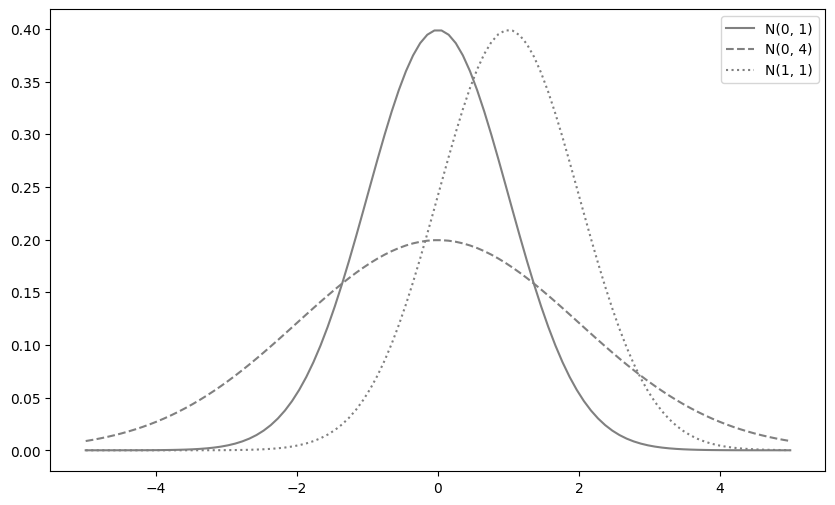

In [ ]:
# N(0,1) -> N(0,4) -> N(1,1)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(-5, 5, 100)
params = [(0, 1), (0, 2), (1, 1)]
for param, ls in zip(params, linestyles):
    mu, sigma = param
    rv = stats.norm(mu, sigma)
    ax.plot(xs, rv.pdf(xs),
            label=f'N({mu}, {sigma**2})', ls=ls, color='gray')
ax.legend()

plt.show()

#### 정규분포의 특징 2가지
* $\sigma^2$이 커짐에 따라 분포가 넓어집니다.
* $\mu$가 변화하면 분포 전체가 평행이동 합니다.
<br>


<center><b>정규분포의 정리</b></center>
$$
\begin{align*}
&\text{파라미터}         && \text{기댓값}\mu, \text{표준편차}\sigma \\
&\text{취할 수 있는 값}   && \text{실수 전체} \\
&\text{밀도함수}         && \frac1{\sqrt{2\pi\sigma}}exp\left\{-\frac{{(x-\mu)}^2}{2\sigma^2}\right\} \\
&\text{기대값}           && \mu \\
&\text{분산}             && \sigma^2 \\
&\text{scipy.stats}      && \mathrm{norm}(\mu,\sigma) \\
\end{align*}
$$
<br>


## 지수분포
* 어떤 사건이 발생하는 간격이 따르는 분포
* 확률변수가 취할 수 있는 값: 0이상의 실수
* 파라미터: $\lambda$
$$
Ex(\lambda)
$$

### 지수분포의 밀도함수
$$
f(x) = \left\{
\begin{array}{ll}
\lambda e^{-\lambda x}, & (x \ge 0) \\
0, & (otherwise)
\end{array}
\right.
$$

\
예) 하루당 편균 2건의 교통사고가 발생하는 지역에서 하루 교통사고 발생 간격
* $Ex(2)$를 따름
* 이 지역에서 교통사고가 일어난 뒤 3일 이내에 또 교통사고가 일어날 확률
$$
P(X \le 3) = \int_0^3 2e^{-2x}dx \simeq 0.998
$$

\
예) 1시간당 평균 10번 엑새스하는 사이트에 대한 액세스 간격
* $Ex(10)$을 따름
* 이 사이트에 대한 액세스가 있은 뒤 1분 이내에 또 액세스할 확률
$$
P(X \le \frac1{60}) = \int_0^{\frac1{60}} 10e^{-10x}dx \simeq 0.154
$$

### 지수분포의 기댓값과 분산
<center>$X \sim Ex(\lambda)$라고 할 때</center><br>
$$
E(X) = \frac1\lambda, \, V(X) = \frac1{\lambda^2}
$$



In [ ]:
# 지수분포의 가능한 값과, 밀도함수 리턴
def Ex(lam):
    x_range = [0, np.inf]
    def f(x):
        if x >= 0:
            return lam * np.exp(-lam * x)
        else:
            return 0
    return x_range, f

In [ ]:
lam = 3
X = Ex(lam)

<br>
기댓값과 분산확인

In [ ]:
check_prob(X)

expected vaue 0.333
variance 0.111


<br>
밀도함수와 분포함수를 0과 2사이에서 그려본다

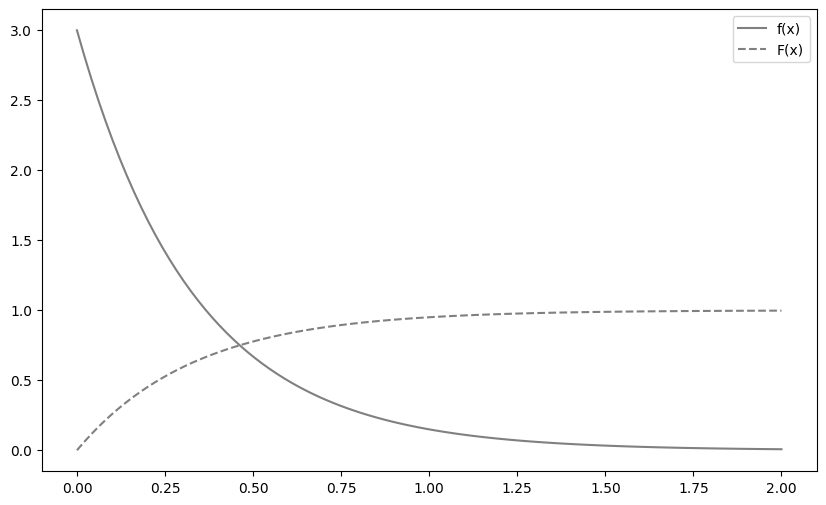

In [ ]:
plot_prob(X, 0, 2)

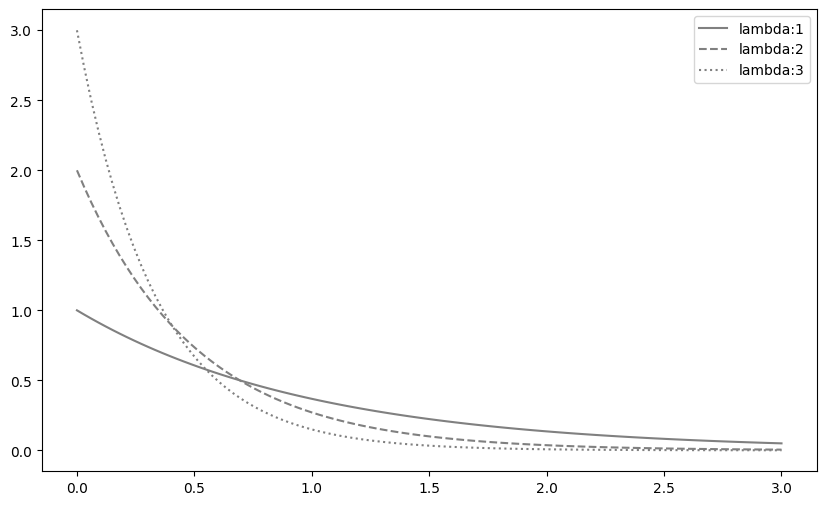

In [ ]:
# lambda: 1 -> 2 -> 3

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(0, 3, 100)
for lam, ls in zip([1, 2, 3], linestyles):
    rv = stats.expon(scale=1/lam)
    ax.plot(xs, rv.pdf(xs),
            label=f'lambda:{lam}', ls=ls, color='gray')
ax.legend()

plt.show()

#### 지수분포의 특징 1가지
* 파라미터 값이 커짐에 따라 확률분포는 점점 감소합니다.

<center><b>지수분포의 정리</b></center>
$$
\begin{align*}
&\text{파라미터}         && \lambda \\
&\text{취할 수 있는 값}   && \text{양의실수} \\
&\text{밀도함수}         && \lambda e^{-\lambda x} \\
&\text{기대값}           && \frac1{\lambda} \\
&\text{분산}             && \frac1{\lambda^2} \\
&\text{scipy.stats}      && \mathrm{expon}(\mathrm{scale}=\frac1{\lambda}) \\
\end{align*}
$$
<br>

## 카이제곱분포

* 추정과 검정에 사용하는 특수한 확률분포
  * 카이제곱분포
  * t분포
  * F분포

* '어떠한 사건이 따른다.'라고 하지 않고 '어떠한 형태를 하고 있다.'고 설명
* 분산의 구간추정이나 독립성 거정에 사용되는 확률분포


<center>$Z_1, Z_2, ... , Z_n$이 서로 독립이고, $N(0,1)$을 따르고 있을 때,</center>
$$
Y = \sum_{i=1}^{n} Z_i^2
$$

* 자유도가 n인 카이제곱분포 표기법: $\chi^2(n)$


In [ ]:
# 표본크기: 10
n = 10
rv = stats.norm()

# 제곱합 100만번 수행
sample_size = int(1e6)

# 표준정규분포로부터 10×100만 사이즈로 무작위추출
Zs_sample = rv.rvs((n, sample_size))

# axis=0에서 총합을 구하고, 표준정규분포의 제곱합 표본 데이터를 구한다
chi2_sample = np.sum(Zs_sample**2, axis=0)

<br>
$Y = \sum_{i=1}^{n}  Z_i^2$에서 추출한 표본데이터의 히스토그램과 , $\chi^2(10)$의 밀도함수 그리기


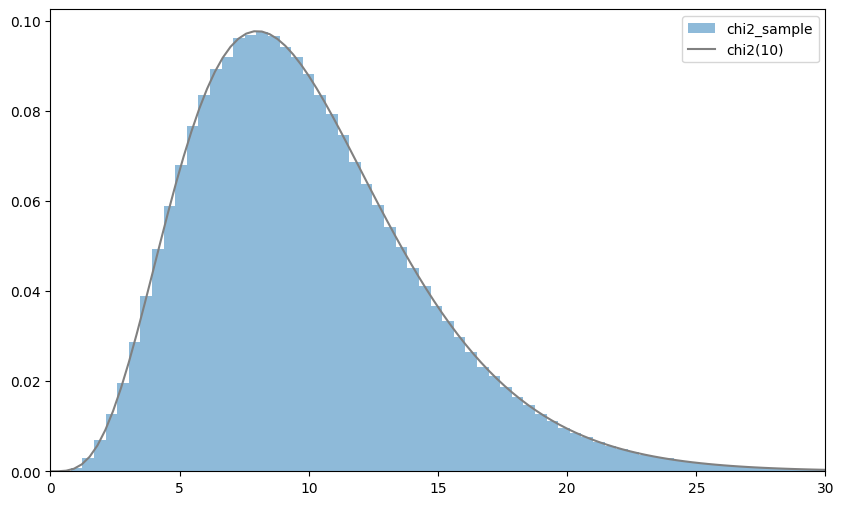

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

rv_true = stats.chi2(n)
xs = np.linspace(0, 30, 100)
ax.hist(chi2_sample, bins=100, density=True,
        alpha=0.5, label='chi2_sample')
ax.plot(xs, rv_true.pdf(xs), label=f'chi2({n})', color='gray')

ax.legend()
ax.set_xlim(0, 30)
plt.show()

히스토그램과 밀도함수가 정확하게 일치하고,
$\sum_{i=1}^{10} Z_i^2 = \chi_2(10)$
이 되는것 확인할 수 있다

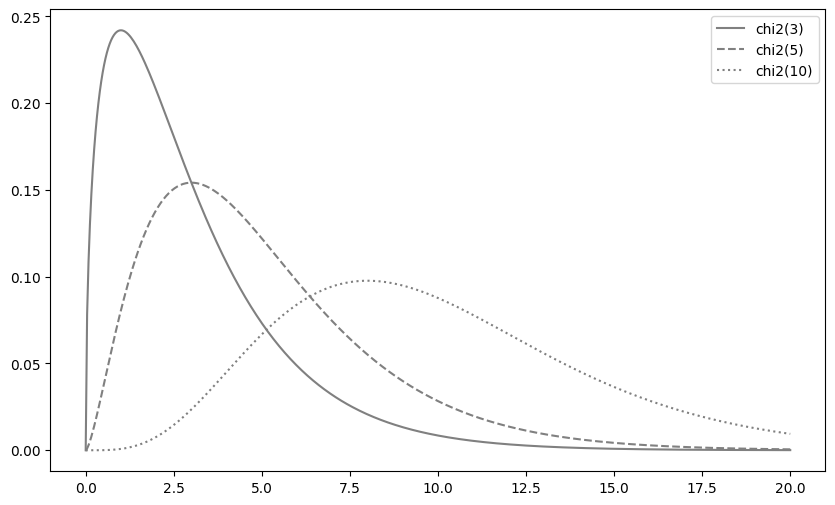

In [ ]:
# 자유도 3 -> 5 -> 10
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(0, 20, 500)
for n, ls in zip([3, 5, 10], linestyles):
    rv = stats.chi2(n)
    ax.plot(xs, rv.pdf(xs),
            label=f'chi2({n})', ls=ls, color='gray')

ax.legend()
plt.show()

### 카이제곱분포($\chi^2$)의 특징 3가지
* 좌우비대칭으로, 왼쪽으로 치우치고 오른쪽으로 넓어집니다.
* 자유도가 커지면 좌우 대친에 가까워집니다.
* 자유도의 값 가까이에 분포의 정점이 있습니다.

#### 자유도가 $n$인 카이제곱분포
* 상위 $100_\alpha\%$점: $\chi_\alpha^2(n)$
* $\chi_\alpha^2(n)$계산: isf메서드

\
$\chi_{0.05}^2(n)$계산


In [ ]:
# 상위 5% 값 계산
rv = stats.chi2(5)
rv.isf(0.05)

np.float64(11.070497693516355)

<center><b>카이제곱분포의 정리</b></center>
$$
\begin{align*}
&\text{파라미터}         && n \\
&\text{취할 수 있는 값}   && \text{음수가 아닌 실수} \\
&\text{scipy.stats}      && \mathrm{chi2}(n) \\
\end{align*}
$$

## t분포
* 정규분포에서 모평균의 구간추정 등에 사용하는 확류분포
* t분포는 서로 독립인 표준정규분포과 카이제곱분포에 의해 다음과 같이 정의함
<br>
<center>
확률변수 $Z, Y$는 서로 독립이고, <br>
$Z$는 표준정규분포 $N(0,1)$을, <br>
$Y$는 자유도가 $n$인 카이제곱분포 $\chi^2(n)$을 각각 따를 때,
</center>
<br>
$$
t = \frac{Z}{\sqrt{Y/n}}
$$
<br>
<center>확률분포를 자유도가 $n$인 t분포라고 함</center>
<br>

* 자유도가 $n$인 $t$분포 표기법: $t(n)$

<br>
표준정규분포와 카이제곱분포로 $t$분포 만들어보기
$Z \sim N(0,1)$과 $Y \sim \chi^2(10)$사용하여 $\frac{Z}{\sqrt{Y/10}}$에서 무작위 추출 수행

In [ ]:
# t(10)
n = 10
rv1 = stats.norm()
rv2 = stats.chi2(n)

sample_size = int(1e6)
Z_sample = rv1.rvs(sample_size)
chi2_sample = rv2.rvs(sample_size)

t_sample = Z_sample / np.sqrt(chi2_sample/n)

<br>
$\frac{Z}{\sqrt{Y/10}}$에서 추출한 표본데이터의 히스토그램과 밀도함수 그리기

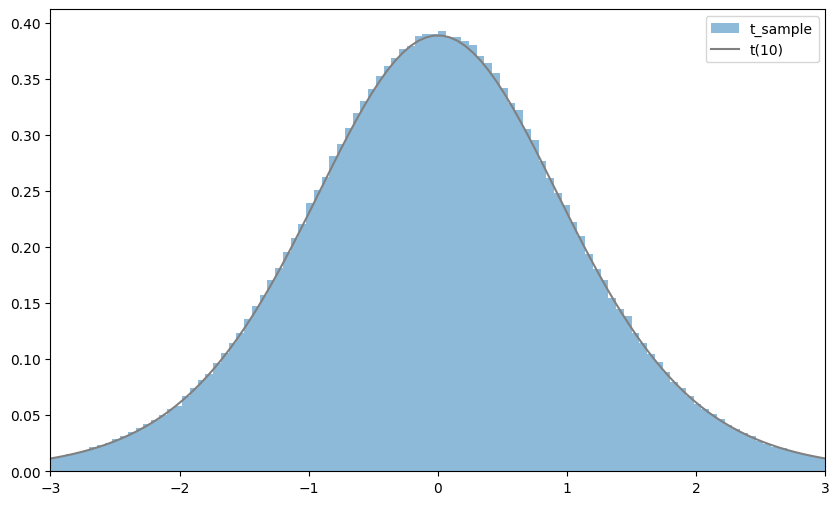

In [ ]:
# sample vs t(10)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

rv = stats.t(n)
xs = np.linspace(-3, 3, 100)

# sample
ax.hist(t_sample, bins=100, range=(-3, 3),
        density=True, alpha=0.5, label='t_sample')

# t(10)
ax.plot(xs, rv.pdf(xs), label=f't({n})', color='gray')

ax.legend()
ax.set_xlim(-3, 3)
plt.show()

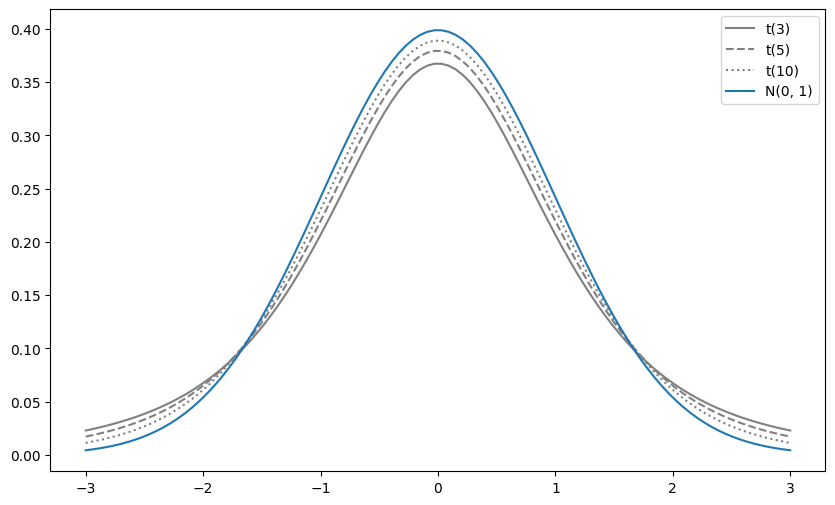

In [ ]:
# 자유도: 3 -> 5 -> 10
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(-3, 3, 100)
for n, ls in zip([3, 5, 10], linestyles):
    rv = stats.t(n)
    ax.plot(xs, rv.pdf(xs),
            label=f't({n})', ls=ls, color='gray')
rv = stats.norm()
ax.plot(xs, rv.pdf(xs), label='N(0, 1)')

ax.legend()
plt.show()

### $t$분포의 특징 3가지
* 좌우대칭인 분포입니다.
* 표준정규분포보다 양쪽 끝이 두껍습니다.
* 자유도가 커지면 표준정규분포에 가까워집니다.

#### 자유도가 $n$인 $t$분포
* 상위 $100_\alpha\%$점: $t_\alpha(n)$
* $t_\alpha(n)$계산: isf메서드

\
$t_{0.05}(n)$계산

In [ ]:
# 상위 5% 값 계산
rv = stats.t(5)
rv.isf(0.05)

np.float64(2.0150483733330233)

<center><b>$t$분포의 정리</b></center>
$$
\begin{align*}
&\text{파라미터}         && n \\
&\text{취할 수 있는 값}   && \text{실수 전체} \\
&\text{scipy.stats}      && \mathrm{t}(n) \\
\end{align*}
$$

## F분포
* 분산분석 등에 사용되는 확률분포
* 서로 독립인 두 개의 카이제곱분포에 의해 다음과 같이 정의

<br>
<center>확률변수 $Y_1, Y_2$는 서로 독립이고, <br>
각각 $Y_1 \sim \chi^2(n_1), Y_2 \sim \chi^2(n_2)$를 따를 때,</center>
<br>
$$
F = \frac{Y_1/n_1}{Y_2/n_2}
$$
<br>
<center>자유도가 $n_1, n_2$인 F분포 $F(n_1, n_2)$라고 함</center>
<br>

* 자유도가 $n_1, n_2$인 F분포 표기법: $F(n_1, n_2)$

$Y_1 \sim \chi^2(5), Y_2 \sim \chi^2(10)$를 사용하여 $\frac{Y_1/5}{Y_2/10}$에서 무작위 추출 수행

In [ ]:
n1 = 5
n2 = 10
rv1 = stats.chi2(n1)
rv2 = stats.chi2(n2)

sample_size = int(1e6)
sample1 = rv1.rvs(sample_size)
sample2 = rv2.rvs(sample_size)

f_sample = (sample1/n1) / (sample2/n2)

$\frac{Y_1/5}{Y_2/10}$의 표본데이터 히스토그램과 $F(5,10)$의 밀도함수 그리기

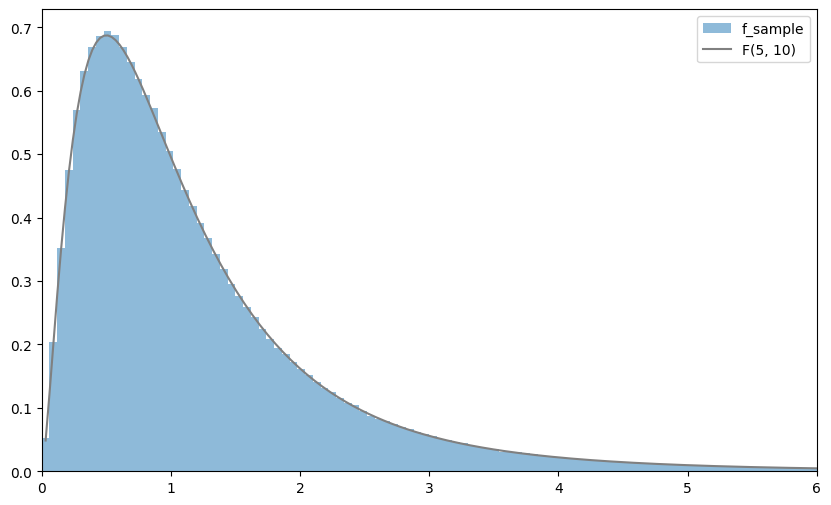

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

rv = stats.f(n1, n2)
xs = np.linspace(0, 6, 200)[1:]
ax.hist(f_sample, bins=100, range=(0, 6),
        density=True, alpha=0.5, label='f_sample')
ax.plot(xs, rv.pdf(xs), label=f'F({n1}, {n2})', color='gray')

ax.legend()
ax.set_xlim(0, 6)
plt.show()

$\frac{Y_1/5}{Y_2/10}$이 $F(5,10)$이 된 것 확인할 수 있음

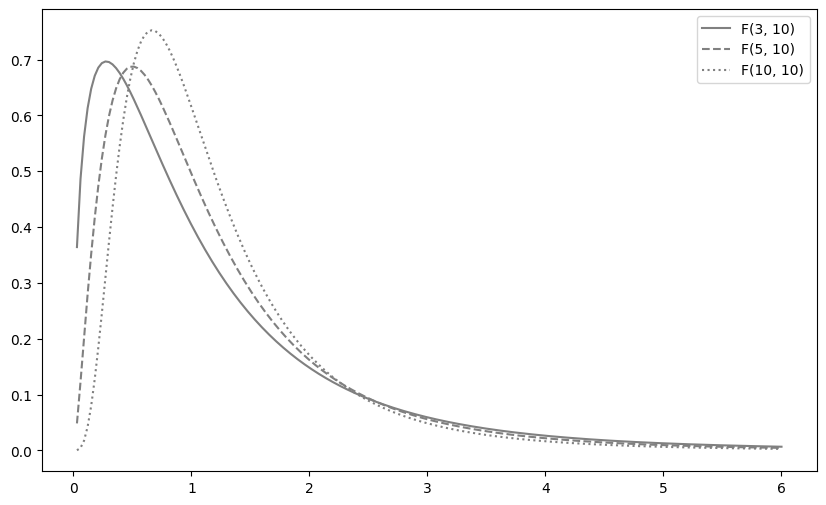

In [ ]:
# 자유도: 3 -> 5 -> 10
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

xs = np.linspace(0, 6, 200)[1:]
for n1, ls in zip([3, 5, 10], linestyles):
    rv = stats.f(n1, 10)
    ax.plot(xs, rv.pdf(xs),
            label=f'F({n1}, 10)', ls=ls, color='gray')

ax.legend()
plt.show()

### F분포의 특징 2가지
* 좌우비대칭으로, 왼쪽으로 치우치고, 오른쪽으로 넓어지는 분포입니다.
* 분포의 정점은 1에 가깝습니다.

<center><b>F분포의 정리</b></center>
$$
\begin{align*}
&\text{파라미터}         && n_1, n_2 \\
&\text{취할 수 있는 값}   && \text{음수가 아닌 실수} \\
&\text{scipy.stats}      && \mathrm{t}(n_1, n_2) \\
\end{align*}
$$